In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
import seaborn as sns
from scipy.signal import find_peaks

from my_funs import *
from sklearn import metrics
from matplotlib import gridspec
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

from matplotlib import dates

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

dongs = ['강남동', '교  동', '근화동', '남  면', '남산면', '동  면', '동내면', '동산면', 
         '북산면','사북면', '서  면', '석사동', '소양동', '신동면', '신북읍', '신사우동', '약사명동', '조운동','퇴계동', 
         '효자1동', '후평1동']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [2]:
def moving_average_alpha_both(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(alpha = unit).mean()

        inv_dong_df = dong_df[::-1]
        for_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()
        
        ewma = (for_ewma + back_ewma) / 2
        ewma = ewma / ewma.max() * max_value
        df['count'][dong_df.index] = ewma 
    
    #print(max_value , df['count'].max())
    return df

def moving_average_com_both(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(com = unit).mean()

        inv_dong_df = dong_df[::-1]
        for_ewma = inv_dong_df['count'].ewm(com = unit).mean()
        
        ewma = (for_ewma + back_ewma) / 2
        ewma = ewma / ewma.max() * max_value
        df['count'][dong_df.index] = ewma 
    
    #print(max_value , df['count'].max())
    return df

def moving_average_span_both(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(span = unit).mean()

        inv_dong_df = dong_df[::-1]
        for_ewma = inv_dong_df['count'].ewm(span = unit).mean()
        
        ewma = (for_ewma + back_ewma) / 2
        ewma = ewma / ewma.max() * max_value
        df['count'][dong_df.index] = ewma 
    
    #print(max_value , df['count'].max())
    return df

def moving_average_halflife_both(df: pd.DataFrame, unit: float):
    ret_df = pd.DataFrame()
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        max_value = dong_df['count'].max()
        back_ewma = dong_df['count'].ewm(halflife = unit).mean()

        inv_dong_df = dong_df[::-1]
        for_ewma = inv_dong_df['count'].ewm(halflife = unit).mean()
        
        ewma = (for_ewma + back_ewma) / 2
        ewma = ewma / ewma.max() * max_value
        df['count'][dong_df.index] = ewma 
    
    #print(max_value , df['count'].max())
    return df

In [27]:
def detail_veiw_ewma_plot(data : pd.DataFrame , title):
    fig = plt.figure(figsize=(15, 15))
    gs = gridspec.GridSpec(nrows = 3, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1], 
                           width_ratios=[1]
                          )
    
    gs.update(wspace=0.1, hspace=0.5)
    ax0 = plt.subplot(gs[0 ,0])
    ax1 = plt.subplot(gs[1 ,0])
    ax2 = plt.subplot(gs[2 ,0])

    
    ax0.set_title(f'1월 5일 ~ 1월 7일  {title}' , fontsize = 20)
    ax1.set_title(f'1월 30일 ~ 2월 1일 {title}', fontsize = 20)
    ax2.set_title(f'2월 19일 ~ 2월 20일{title}', fontsize = 20)
    
    org_data = data_processing('../../test.csv',0 , None)
    org_data = org_data[org_data['h_dong'] == '강남동']
    org_data.reset_index(inplace=True, drop=True)
    
    ewma_data = data[data['h_dong'] == '강남동']
    ewma_data.reset_index(inplace=True, drop=True)
    
    s1 , e1 = 96 , 144
    ax0.plot(org_data['REG_DTIME'].loc[s1:e1] ,org_data['count'].loc[s1:e1], label = '원본 데이터')
    ax0.plot(ewma_data['REG_DTIME'].loc[s1:e1] ,ewma_data['count'].loc[s1:e1] , label = 'ewma 적용 데이터')
    ax0.xaxis.set_major_locator(dates.HourLocator())
    ax0.set_xticklabels(ax0.get_xticks(), rotation = 45 ,fontsize=8)
    ax0.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax0.legend()
    
    s2 , e2 = 696 , 744
    ax1.plot(org_data['REG_DTIME'].loc[s2:e2] ,org_data['count'].loc[s2:e2], label = '원본 데이터')
    ax1.plot(ewma_data['REG_DTIME'].loc[s2:e2] ,ewma_data['count'].loc[s2:e2] , label = 'ewma 적용 데이터')
    ax1.xaxis.set_major_locator(dates.HourLocator())
    ax1.set_xticklabels(ax1.get_xticks(), rotation = 45 ,fontsize=8)
    ax1.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax1.legend()
    
    s3 , e3= 1176 , 1200
    ax2.plot(org_data['REG_DTIME'].loc[s3:e3] ,org_data['count'].loc[s3:e3], label = '원본 데이터')
    ax2.plot(ewma_data['REG_DTIME'].loc[s3:e3] ,ewma_data['count'].loc[s3:e3] , label = 'ewma 적용 데이터')
    ax2.xaxis.set_major_locator(dates.HourLocator())
    ax2.set_xticklabels(ax2.get_xticks(), rotation = 45,fontsize=8)
    ax2.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax2.legend()
    
    
def detail_veiw_ewma_scatter(data : pd.DataFrame, title):
    fig = plt.figure(figsize=(15, 15))
    gs = gridspec.GridSpec(nrows = 3, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1], 
                           width_ratios=[1]
                          )
    
    gs.update(wspace=0.1, hspace=0.5)
    ax0 = plt.subplot(gs[0 ,0])
    ax1 = plt.subplot(gs[1 ,0])
    ax2 = plt.subplot(gs[2 ,0])
    s_size = 4
    
    ax0.set_title(f'1월 5일 ~ 1월 7일  {title}' , fontsize = 20)
    ax1.set_title(f'1월 30일 ~ 2월 1일 {title}', fontsize = 20)
    ax2.set_title(f'2월 19일 ~ 2월 20일{title}', fontsize = 20)
    
    org_data = data_processing('../../test.csv',0 , None)
    org_data = org_data[org_data['h_dong'] == '강남동']
    org_data.reset_index(inplace=True, drop=True)
    
    ewma_data = data[data['h_dong'] == '강남동']
    ewma_data.reset_index(inplace=True, drop=True)
    
    s1 , e1 = 96 , 144
    ax0.scatter(org_data['REG_DTIME'].loc[s1:e1] ,org_data['count'].loc[s1:e1], label = '원본 데이터', s = s_size)
    ax0.scatter(ewma_data['REG_DTIME'].loc[s1:e1] ,ewma_data['count'].loc[s1:e1] , label = 'ewma 적용 데이터', s = s_size)
    ax0.xaxis.set_major_locator(dates.HourLocator())
    ax0.set_xticklabels(ax0.get_xticks(), rotation = 45 ,fontsize=8)
    ax0.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax0.legend()
    
    s2 , e2 = 696 , 744
    ax1.scatter(org_data['REG_DTIME'].loc[s2:e2] ,org_data['count'].loc[s2:e2], label = '원본 데이터', s = s_size)
    ax1.scatter(ewma_data['REG_DTIME'].loc[s2:e2] ,ewma_data['count'].loc[s2:e2] , label = 'ewma 적용 데이터', s = s_size)
    ax1.xaxis.set_major_locator(dates.HourLocator())
    ax1.set_xticklabels(ax1.get_xticks(), rotation = 45 ,fontsize=8)
    ax1.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax1.legend()
    
    s3 , e3= 1176 , 1200
    ax2.scatter(org_data['REG_DTIME'].loc[s3:e3] ,org_data['count'].loc[s3:e3], label = '원본 데이터', s = s_size)
    ax2.scatter(ewma_data['REG_DTIME'].loc[s3:e3] ,ewma_data['count'].loc[s3:e3] , label = 'ewma 적용 데이터', s = s_size)
    ax2.xaxis.set_major_locator(dates.HourLocator())
    ax2.set_xticklabels(ax2.get_xticks(), rotation = 45 ,fontsize=8)
    ax2.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))
    ax2.legend()
    

## plot 과 scatter 두 가지 버전으로 제작

* 1월 5일 ~ 1월 7일
* 1월 30일 ~ 2월 1일
* 2월 19일 ~ 2월 20일    

세 개의 구간으로 확인 

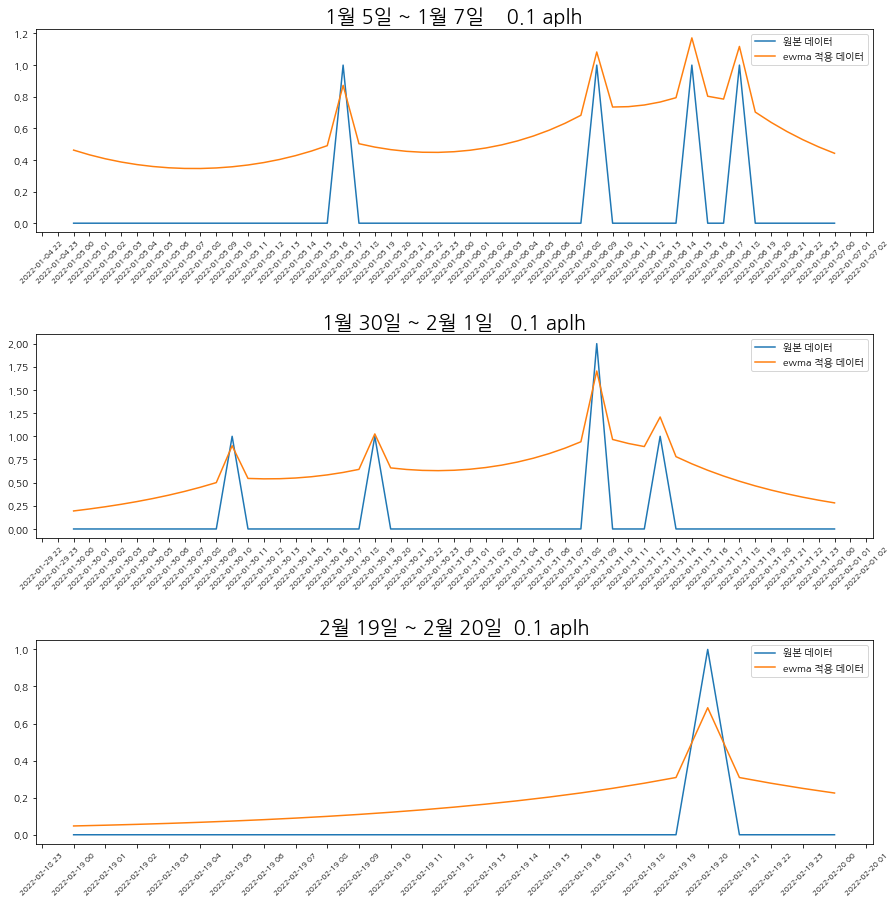

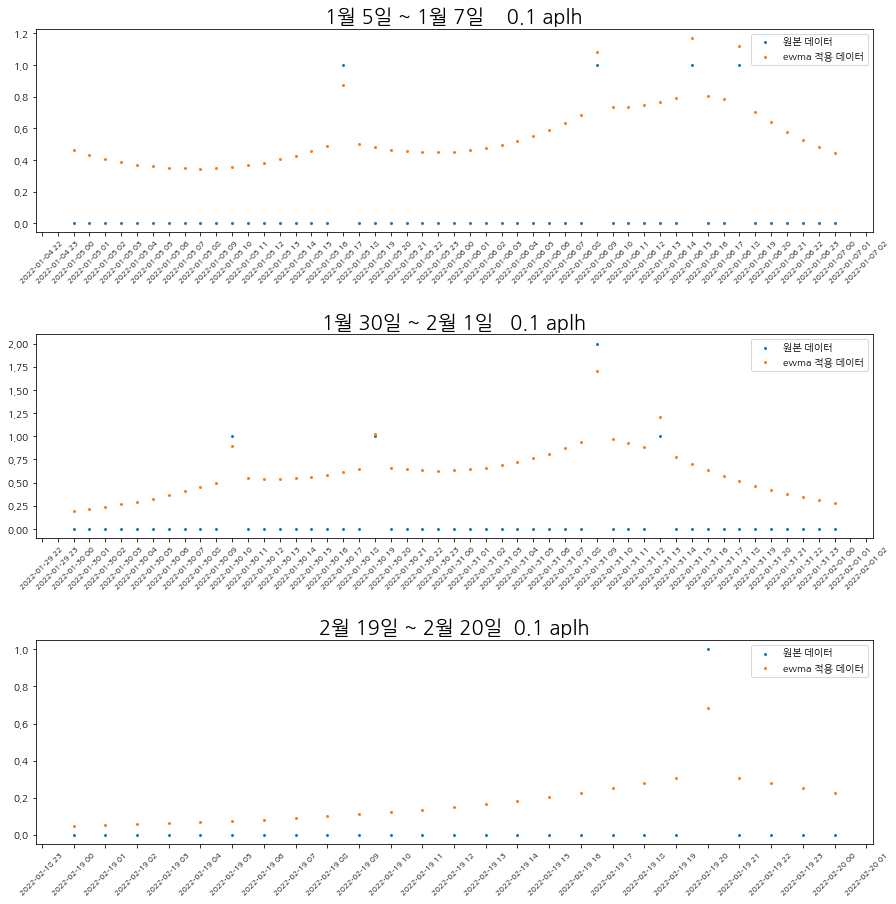

In [28]:
test_data = data_processing('../../test.csv' , 0.1, moving_average_alpha_both)
detail_veiw_ewma_plot(test_data , '  0.1 aplh')
detail_veiw_ewma_scatter(test_data,'  0.1 aplh')

## alpha scatter
0 ~ 0.9 까지 0.1 단위로 계산

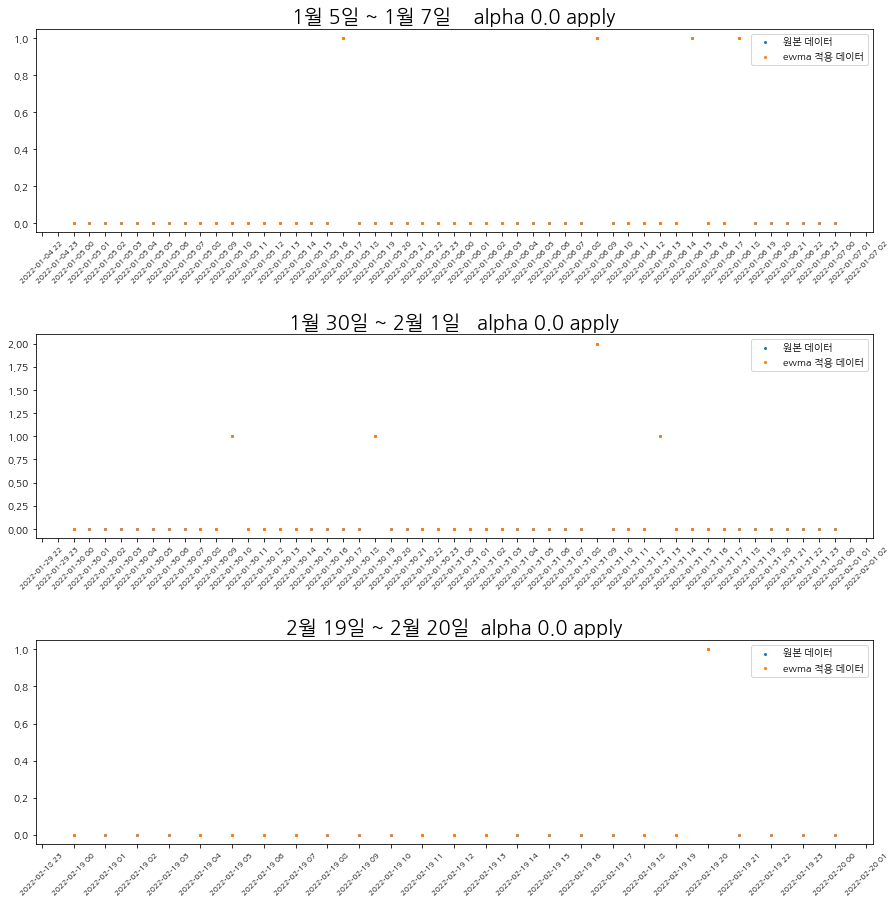

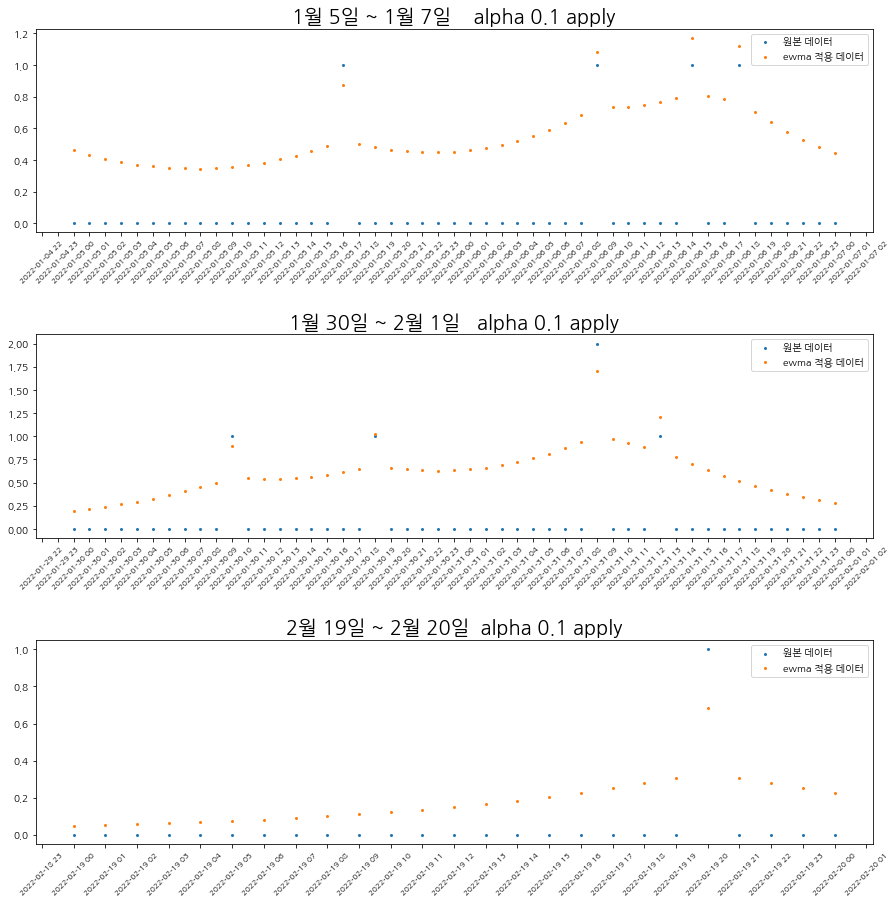

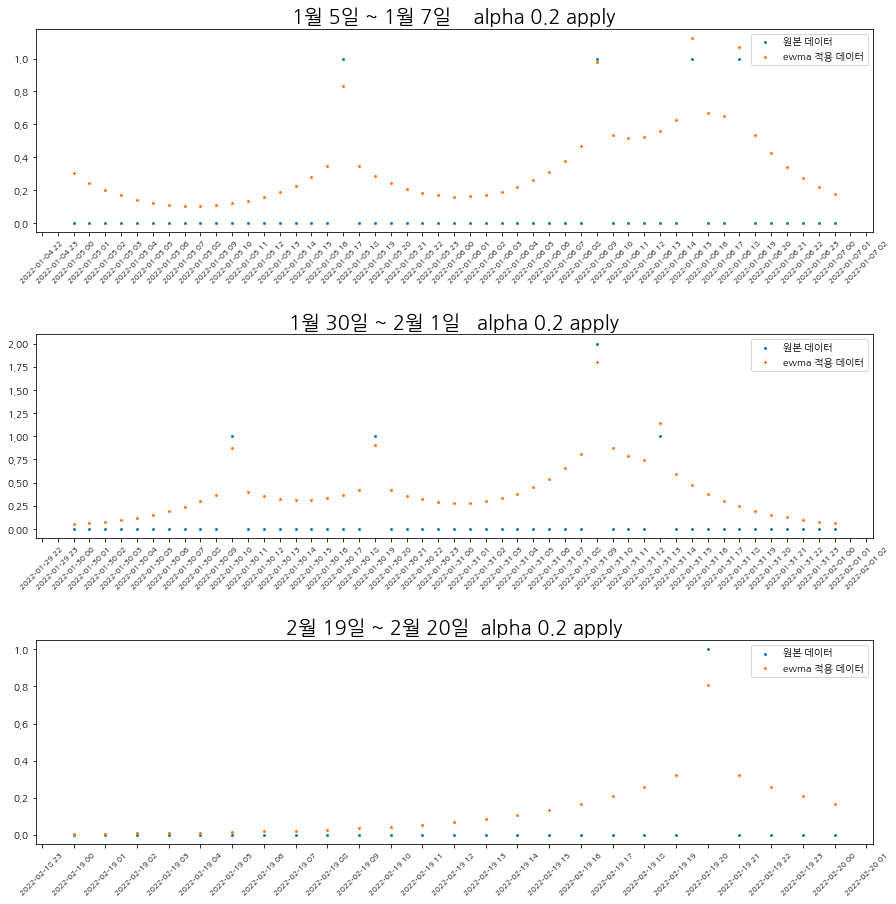

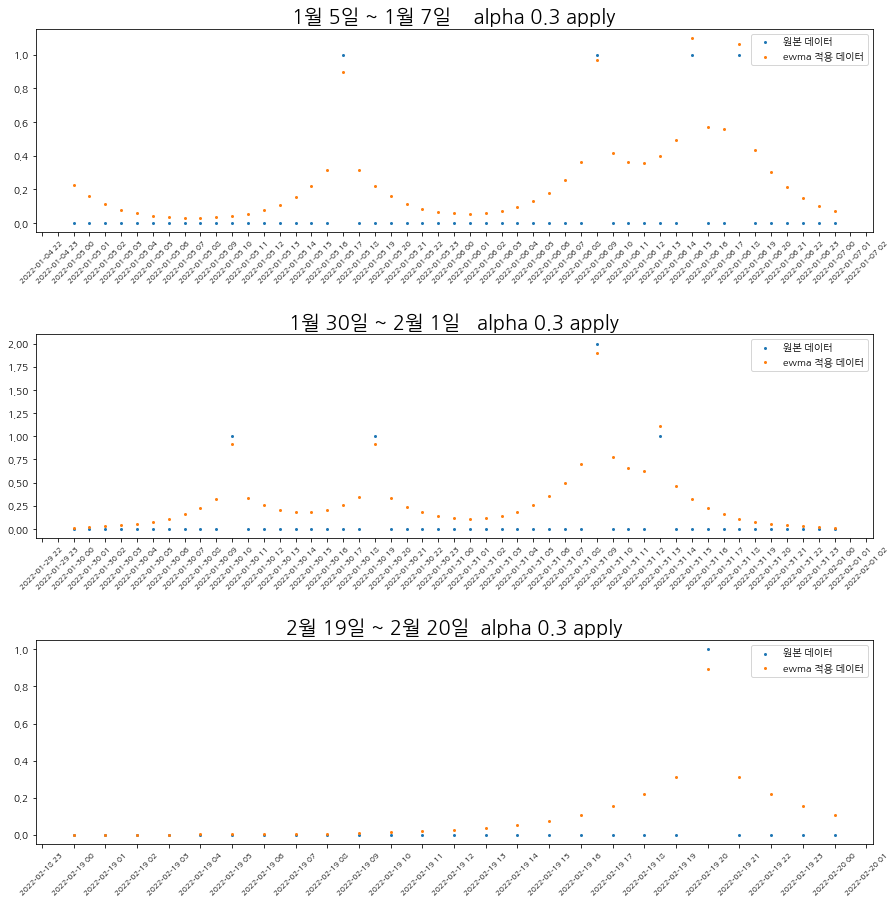

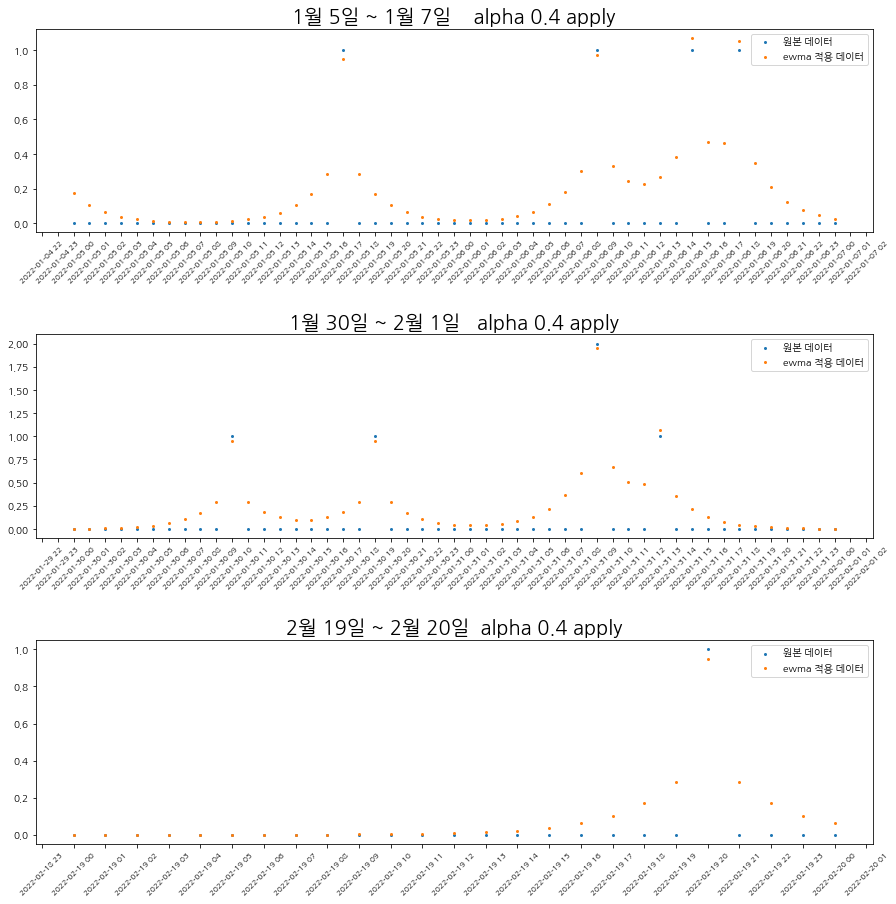

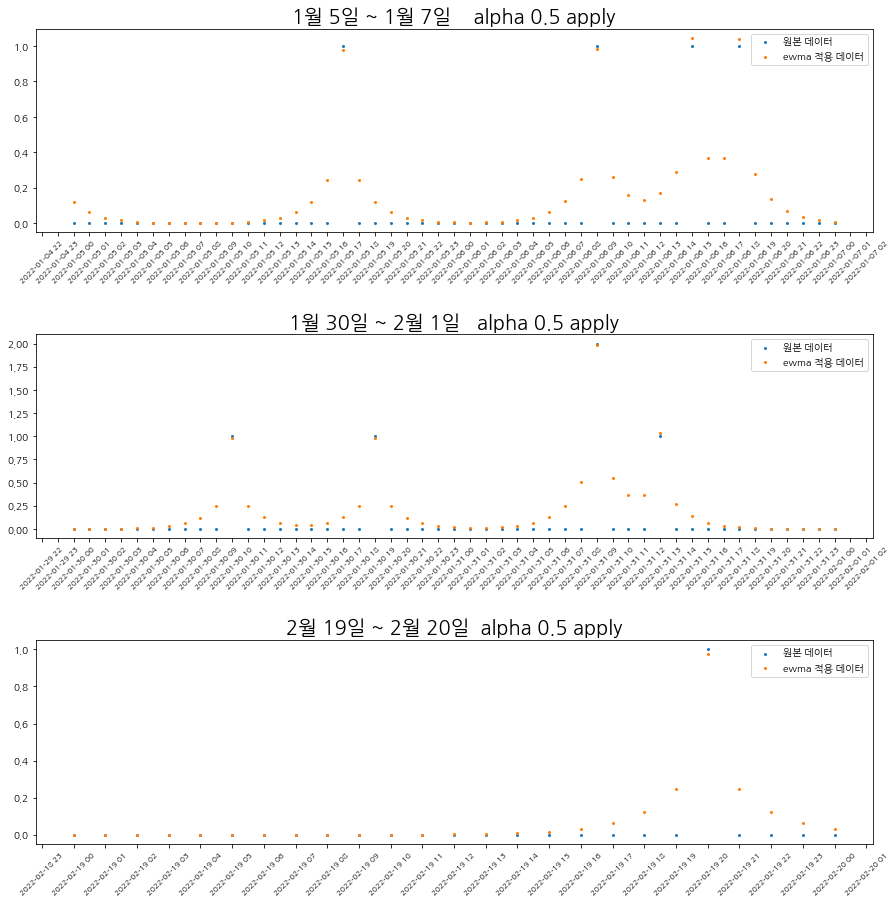

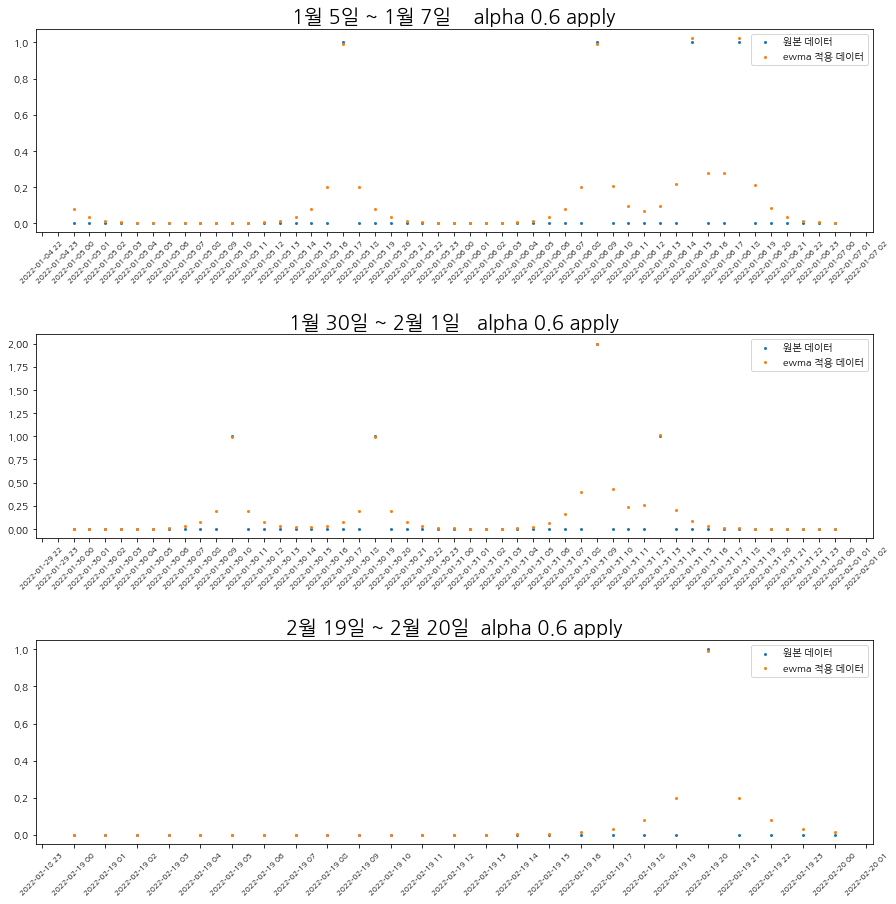

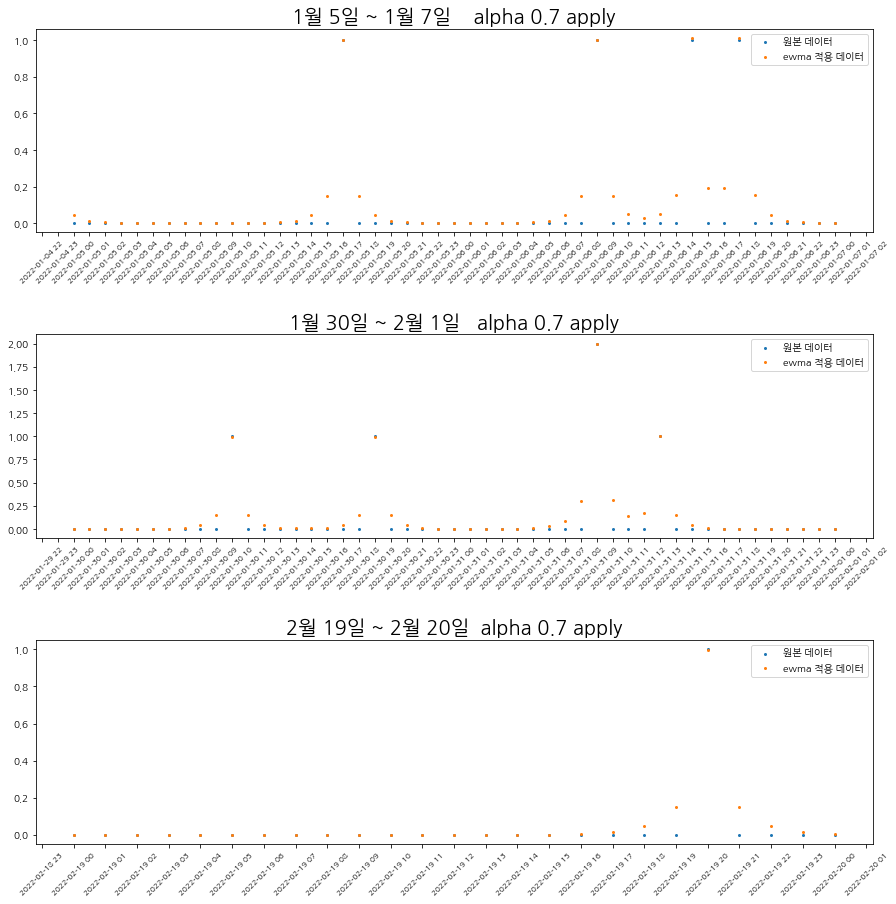

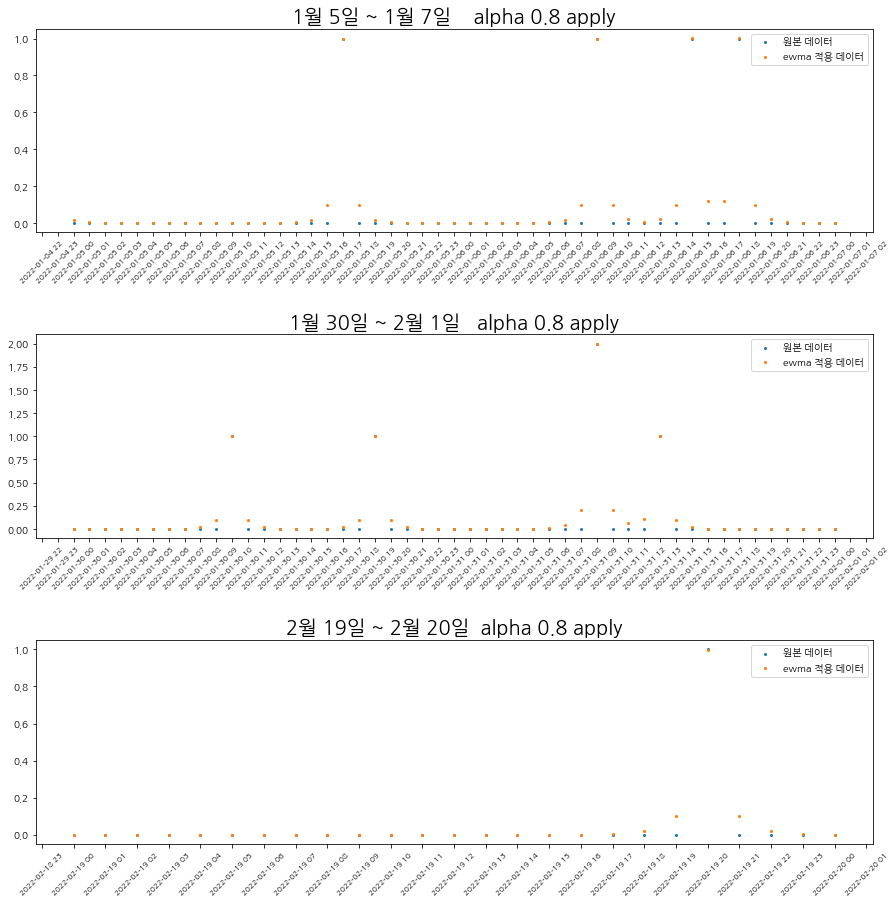

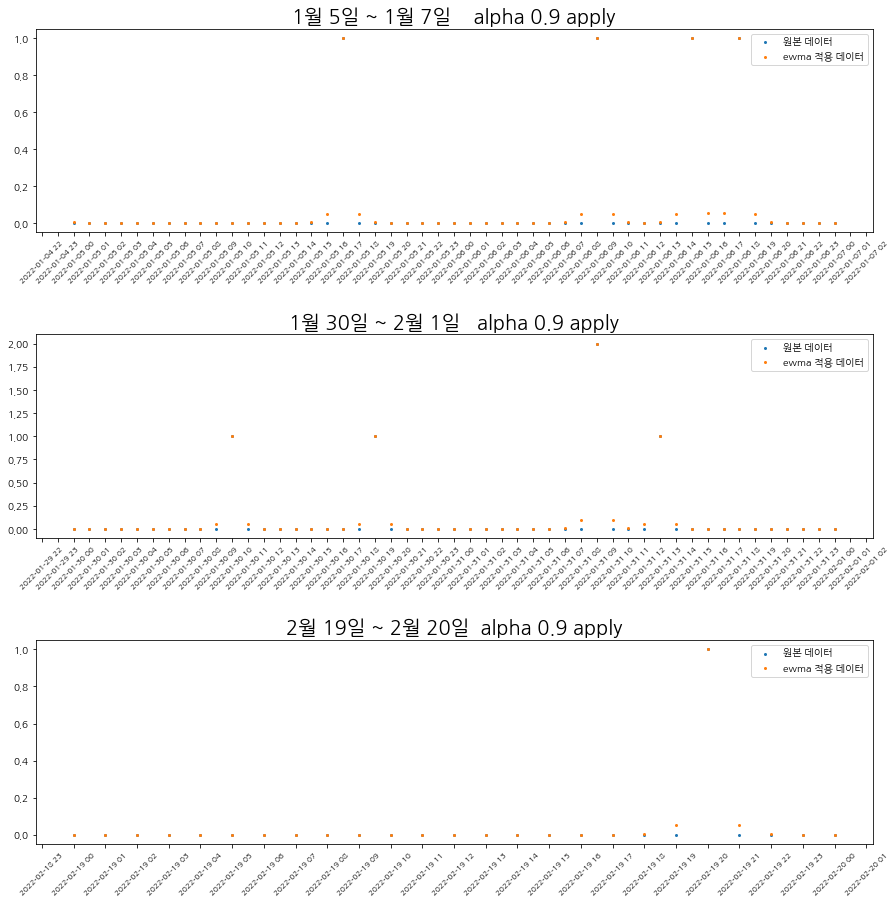

In [29]:
for factor in np.arange(0,10) / 10:
    test_data = data_processing('../../test.csv' , factor, moving_average_alpha_both)
    #detail_veiw_ewma_plot(test_data , f'  alpha {factor} apply')
    detail_veiw_ewma_scatter(test_data,f'  alpha {factor} apply')

## com scatter
1 ~ 10 까지 1 단위로 계산

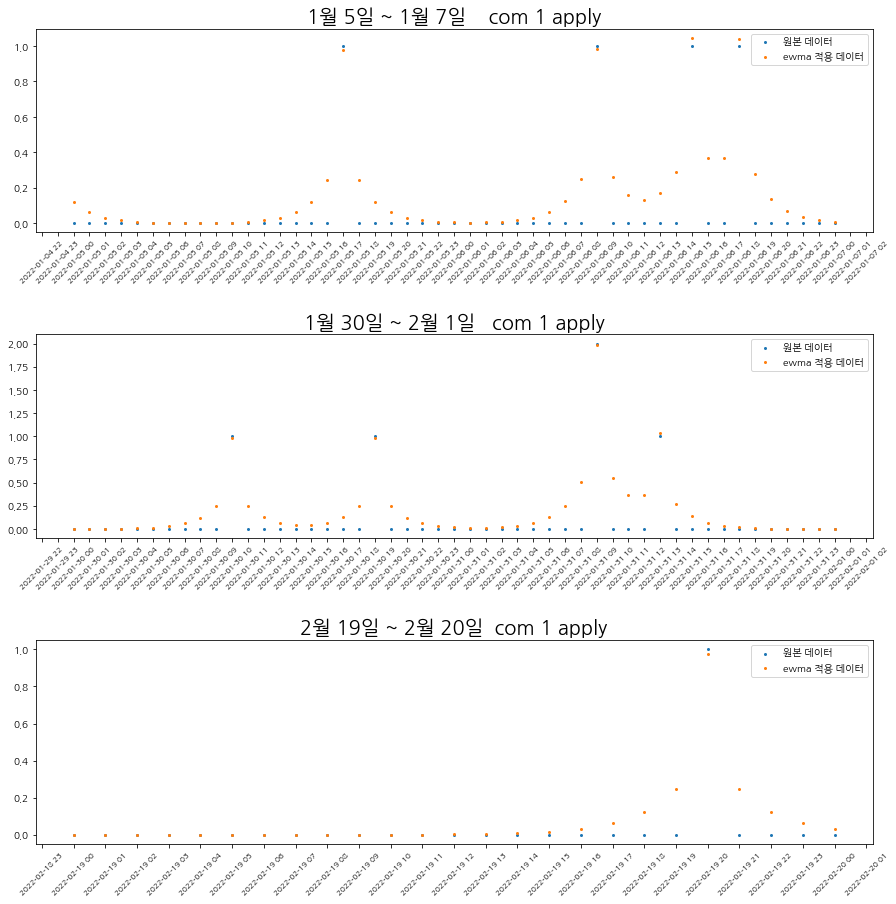

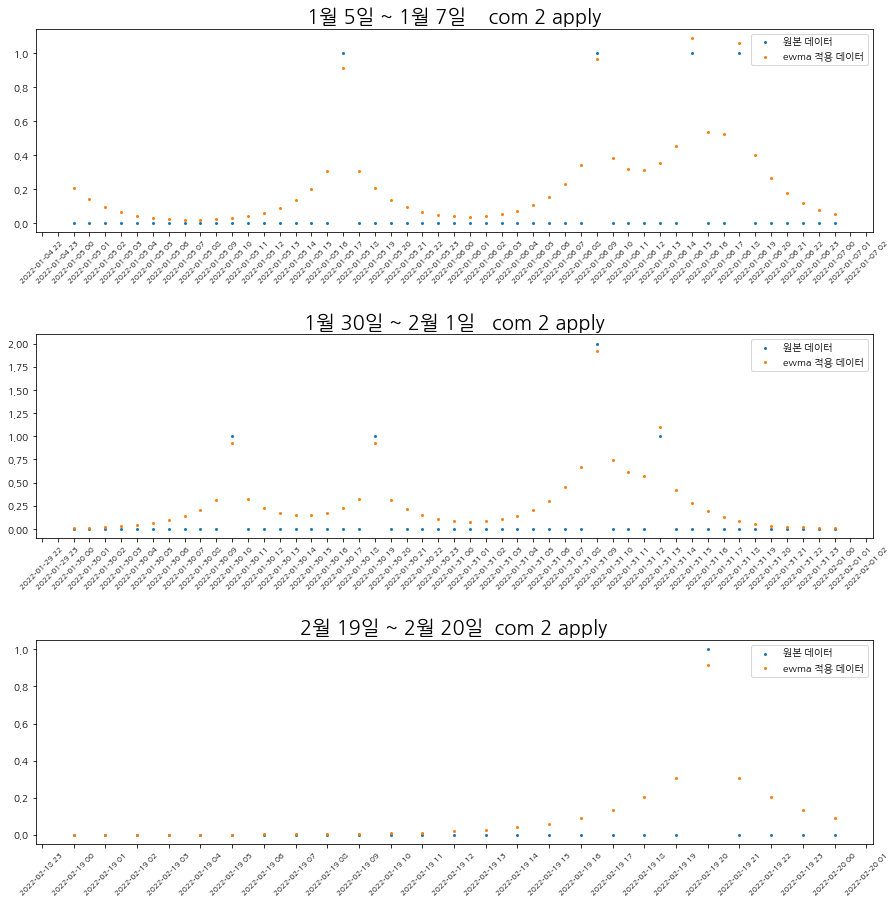

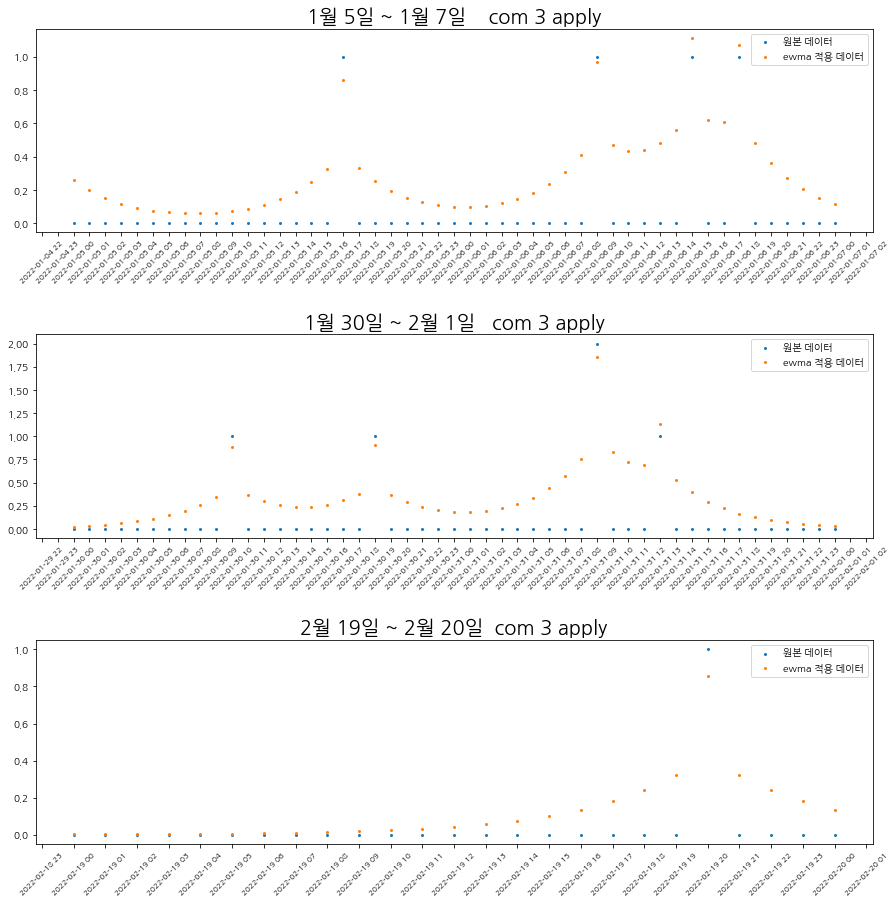

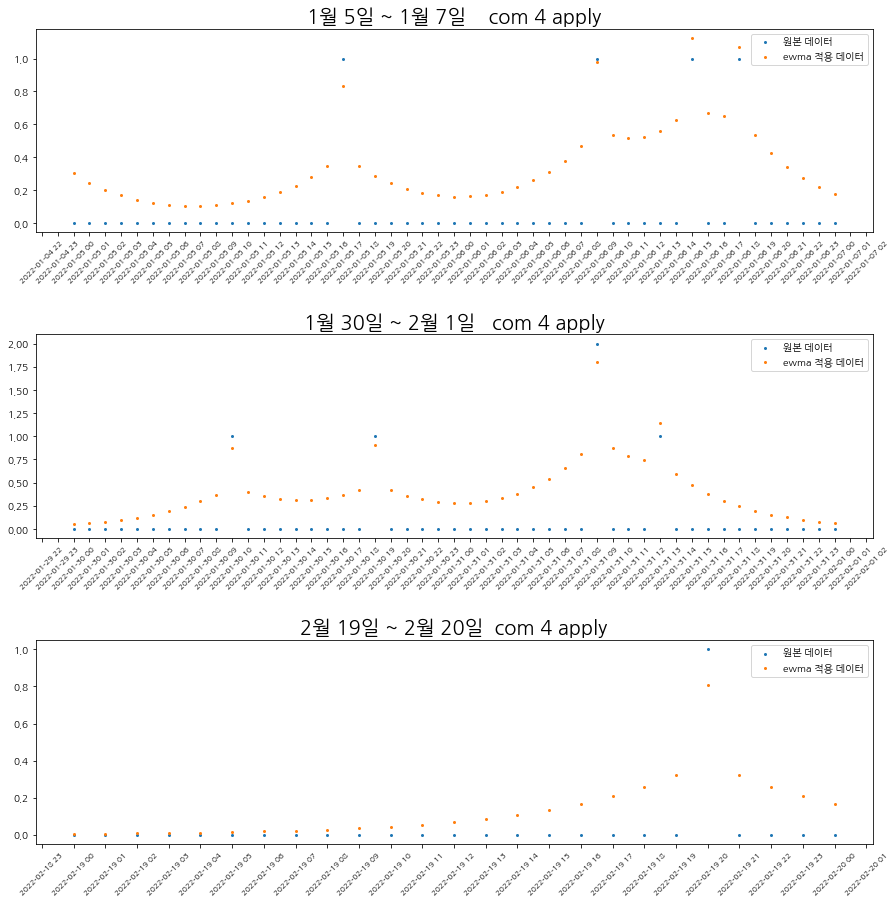

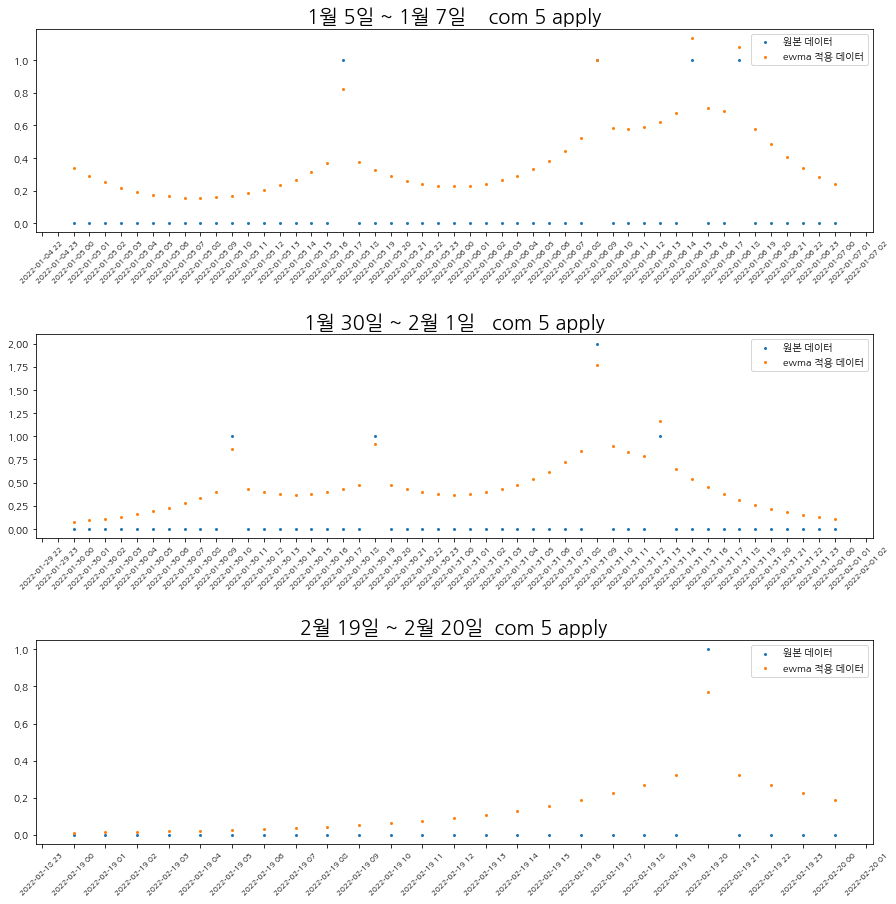

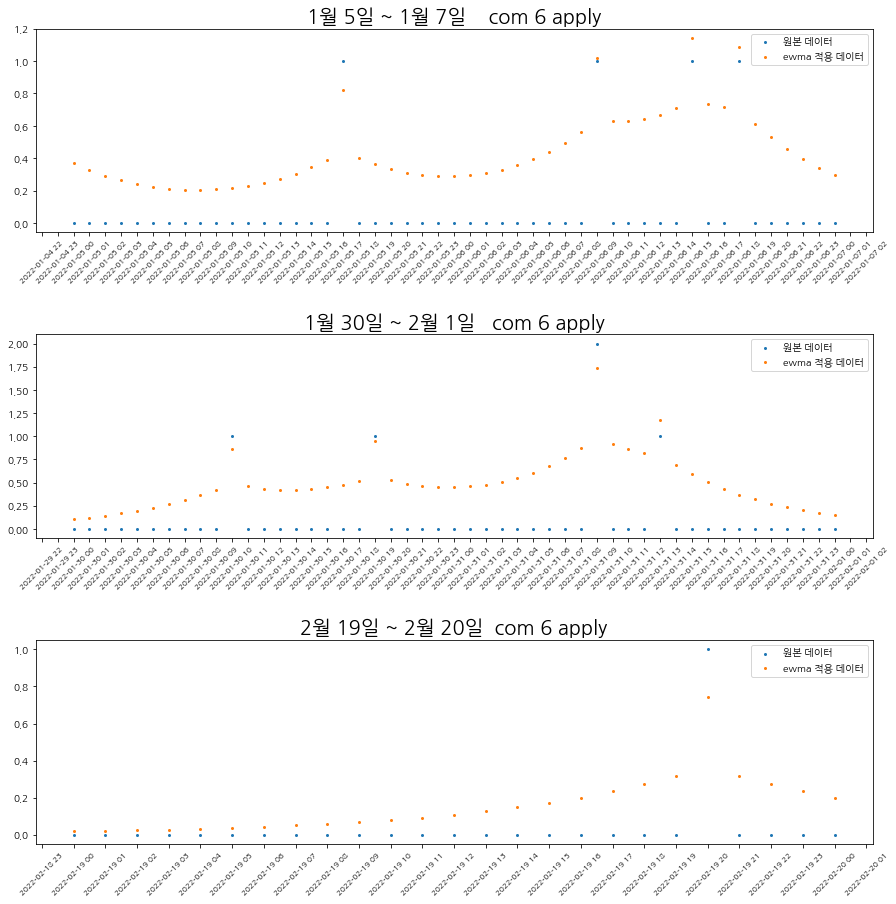

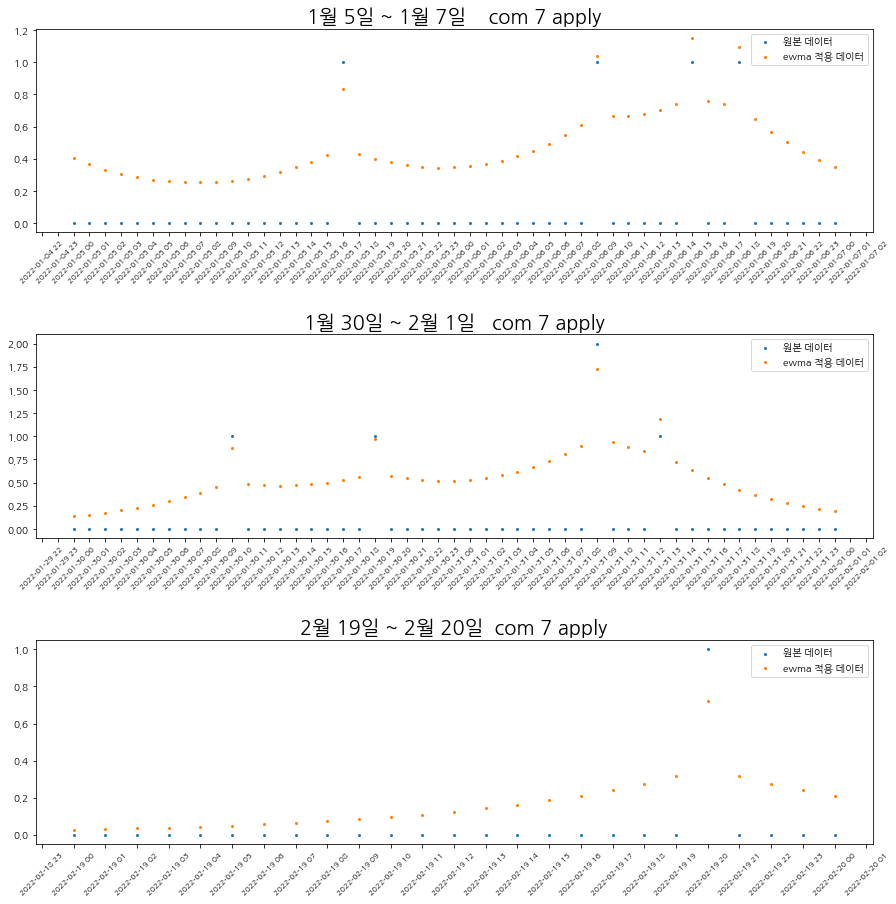

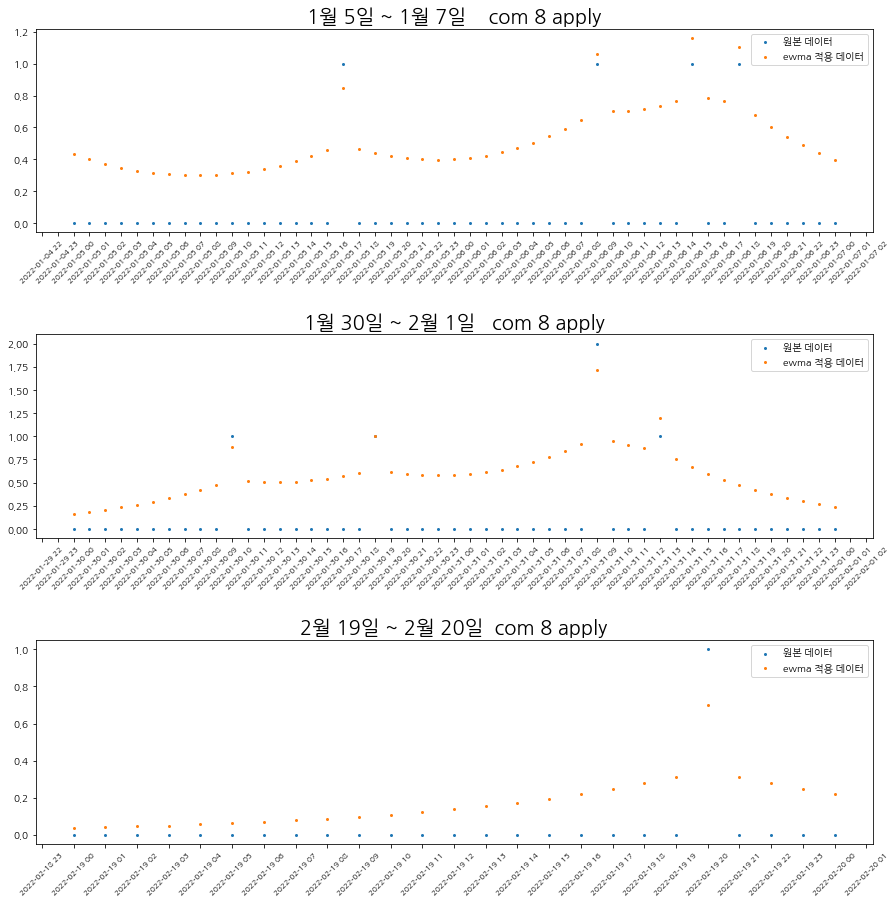

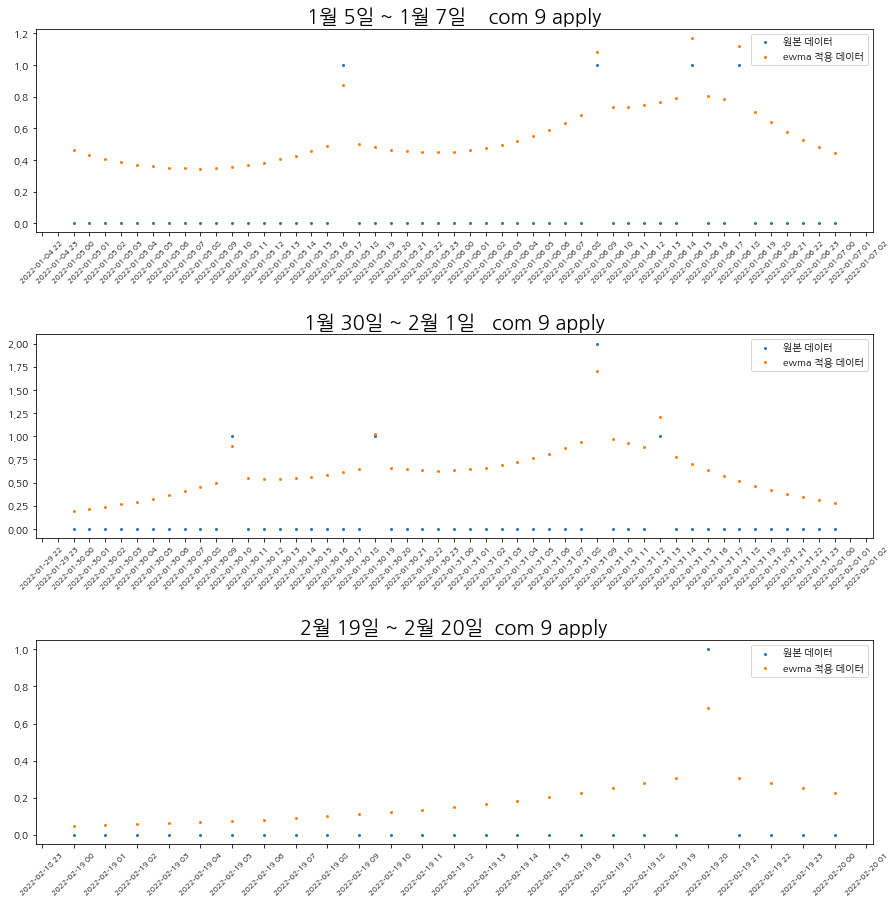

In [30]:
for factor in np.arange(1,10) :
    test_data = data_processing('../../test.csv' , factor, moving_average_com_both)
    #detail_veiw_ewma_plot(test_data , f'  com {factor} apply')
    detail_veiw_ewma_scatter(test_data,f'  com {factor} apply')

## span scatter
1 ~ 10 까지 1 단위로 계산

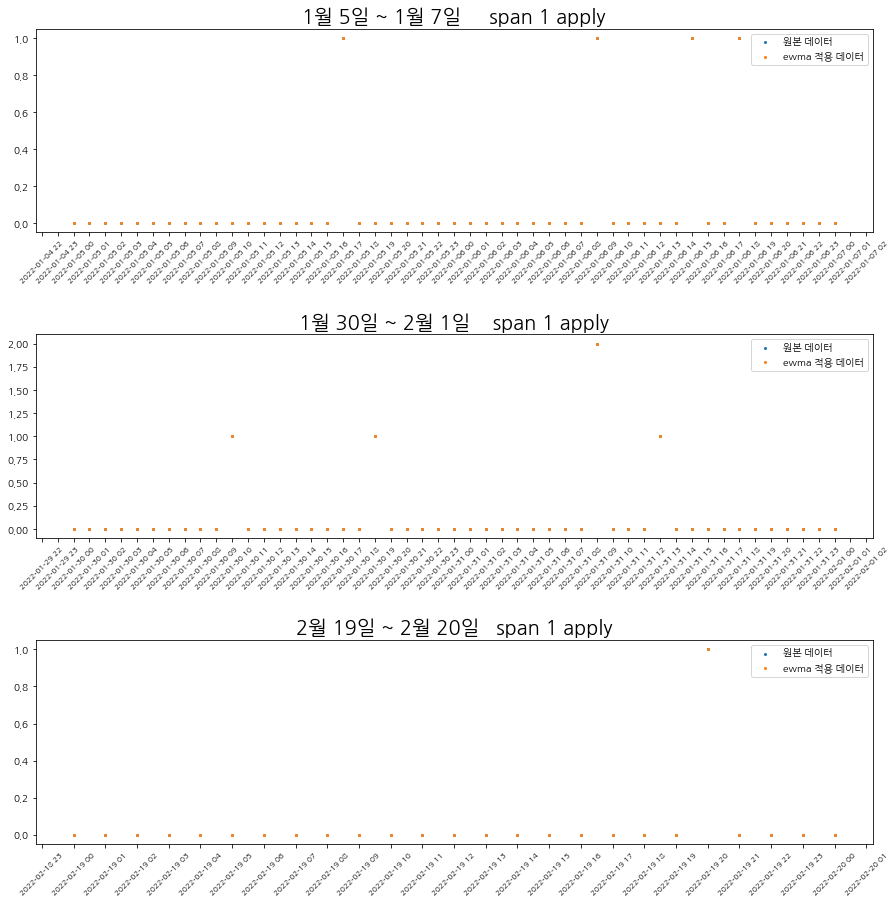

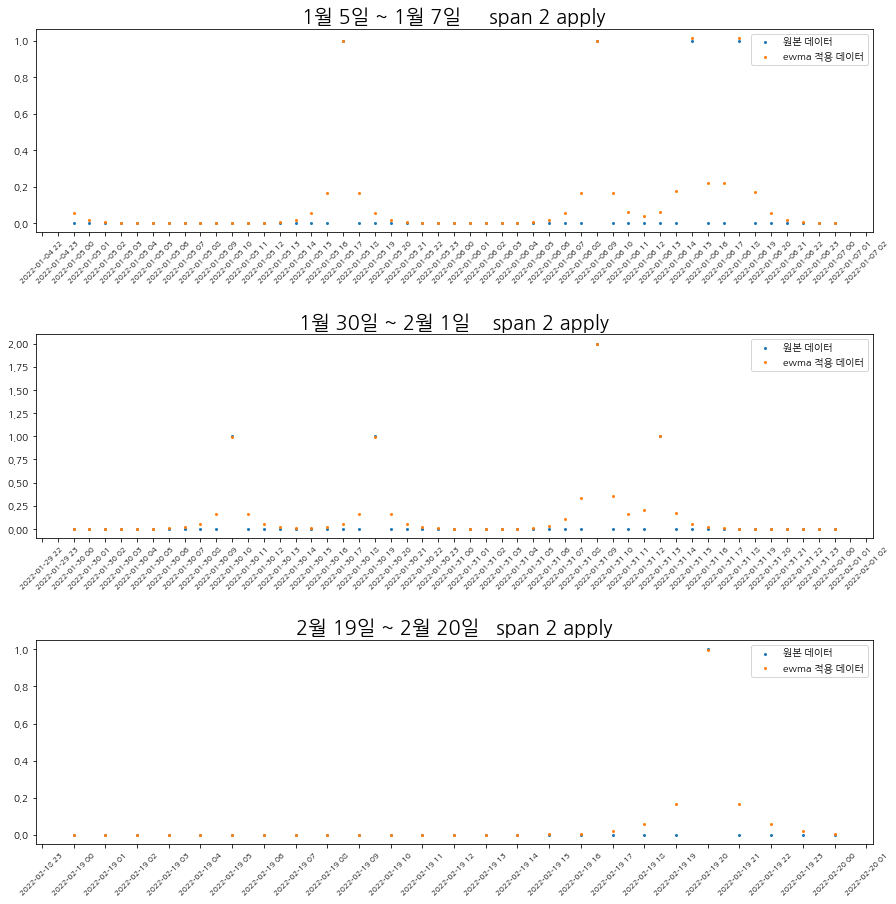

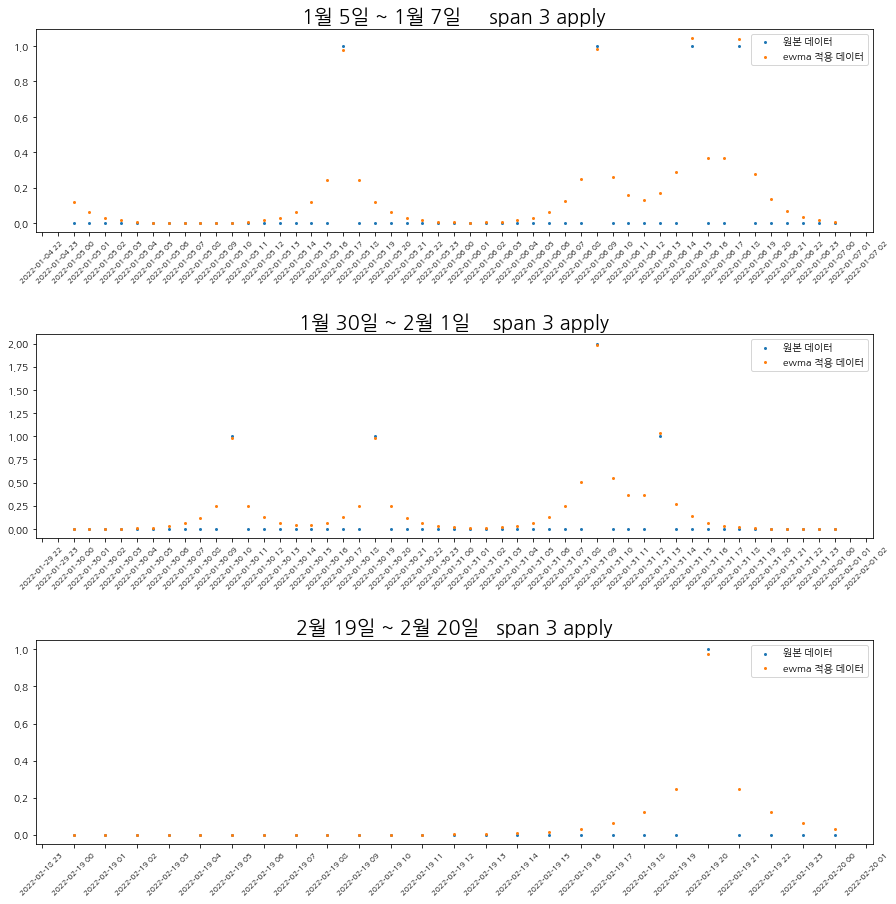

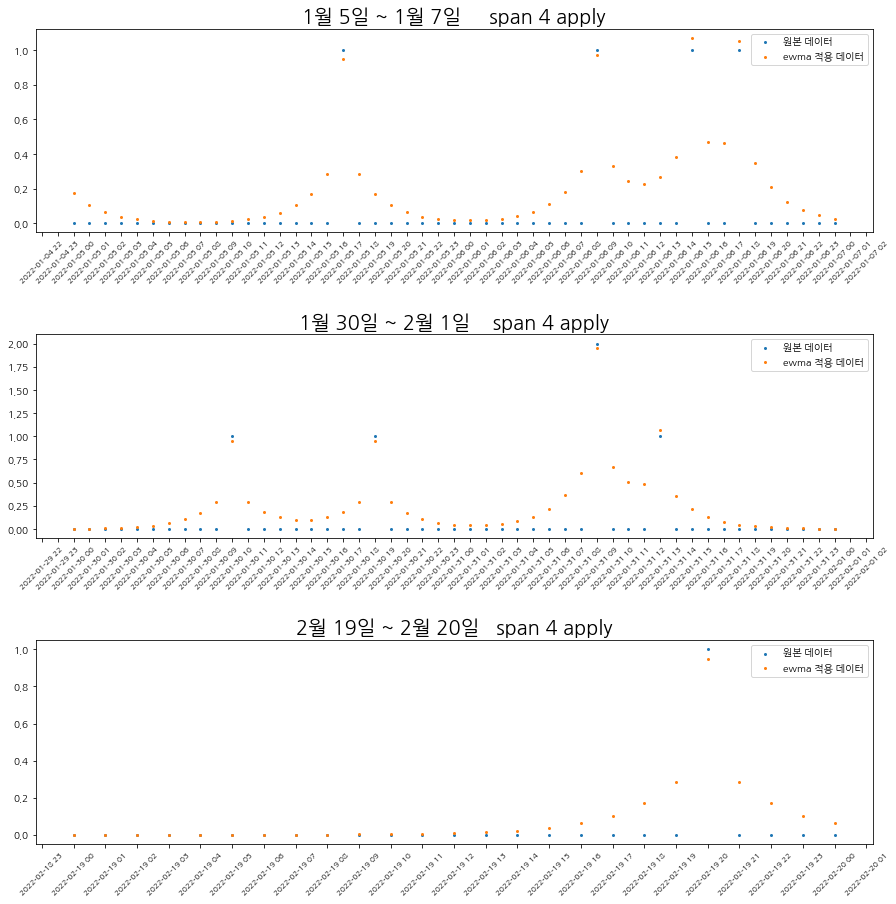

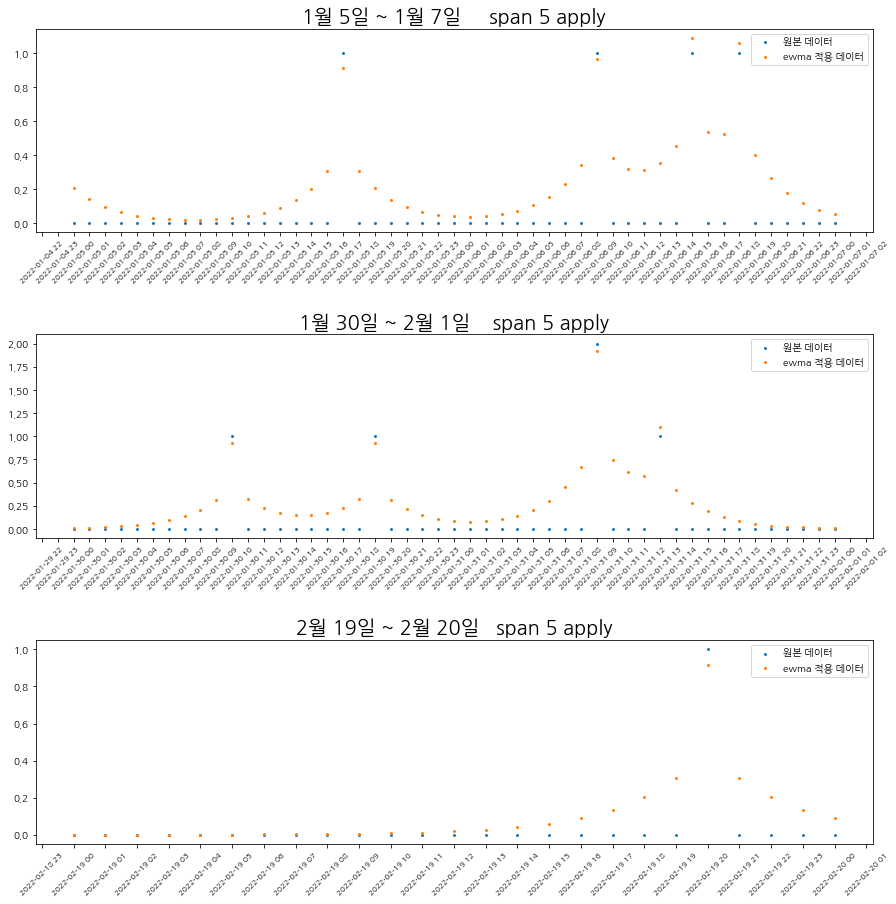

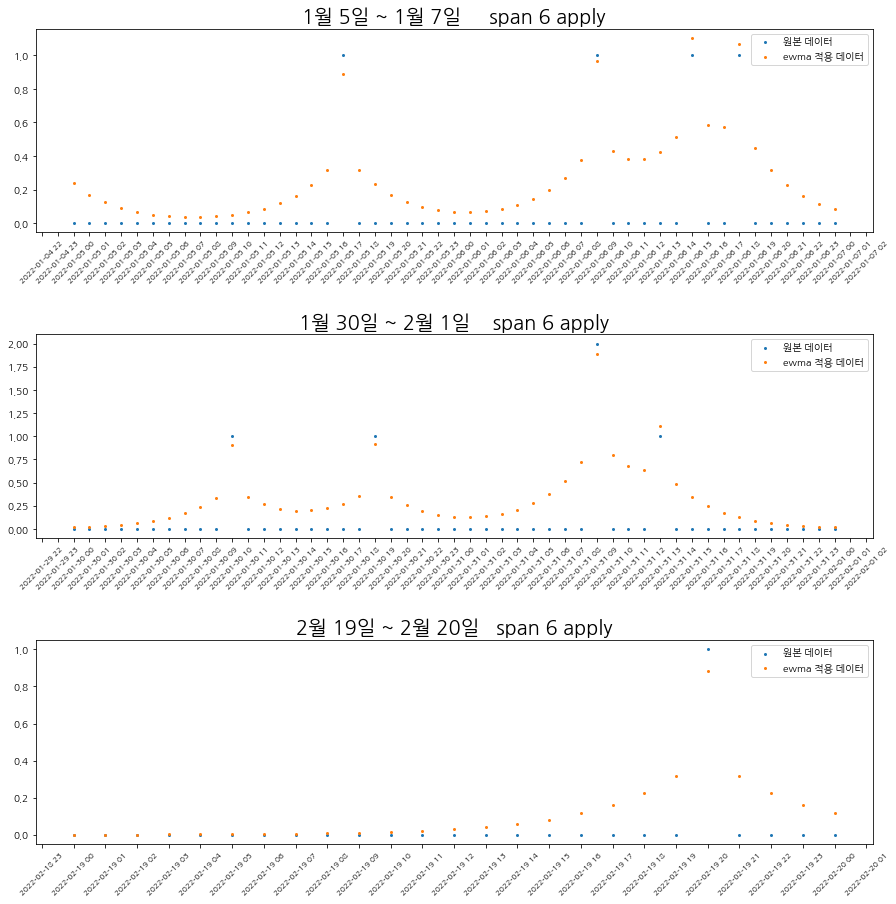

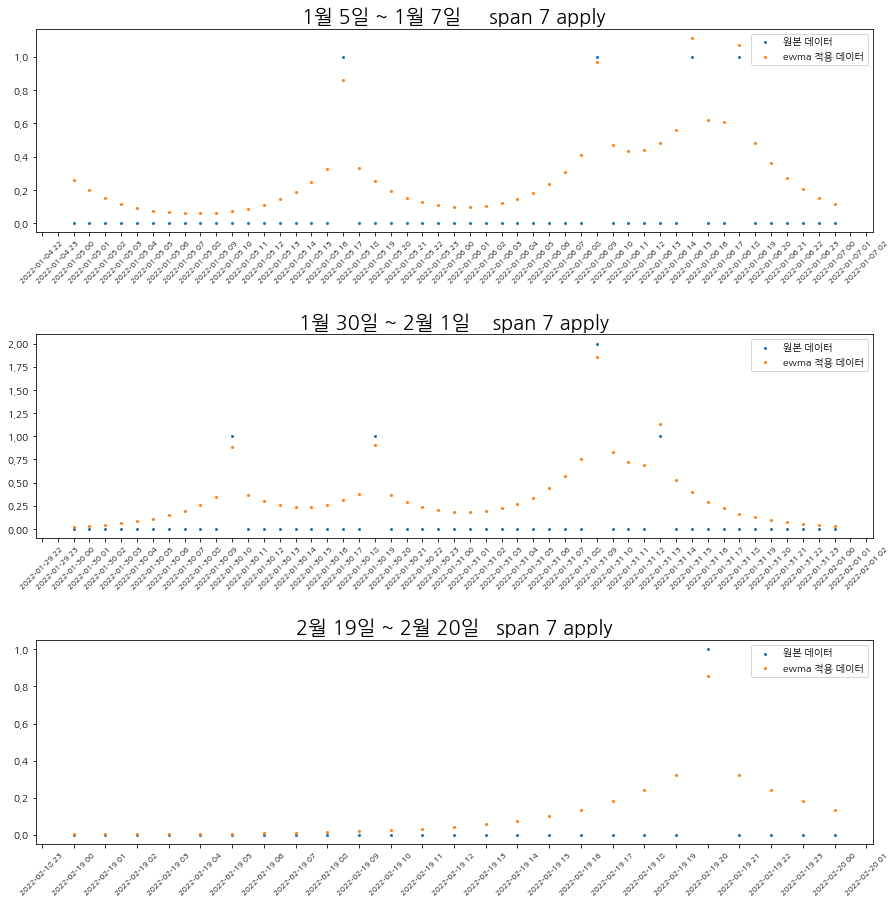

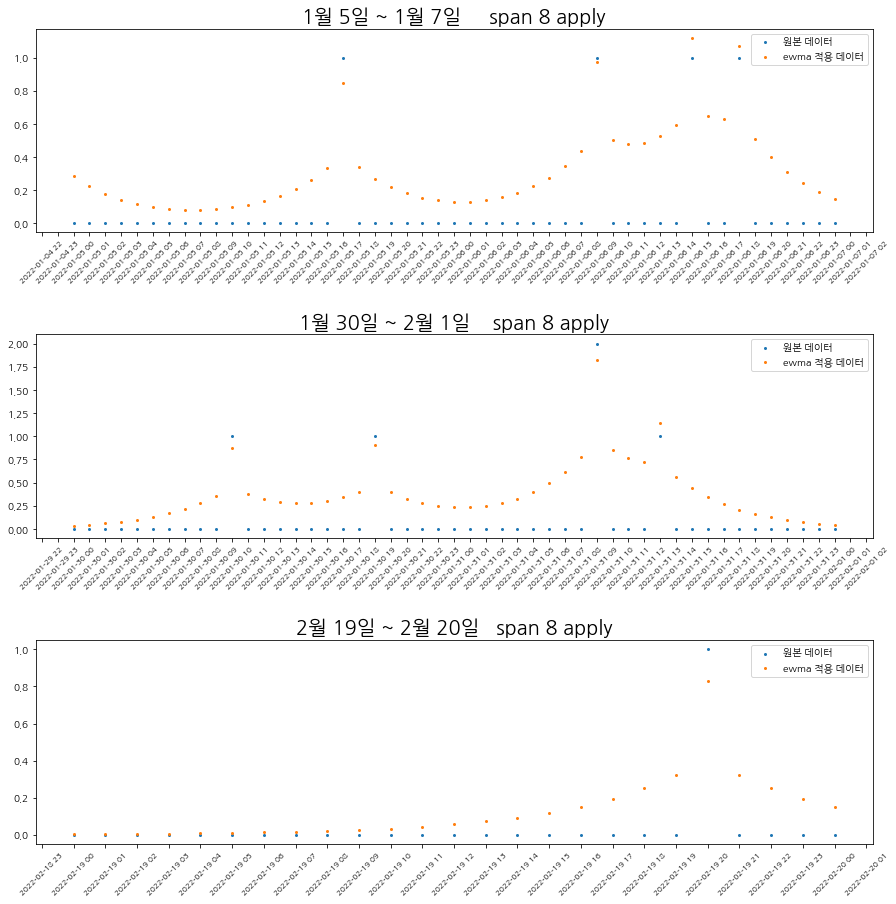

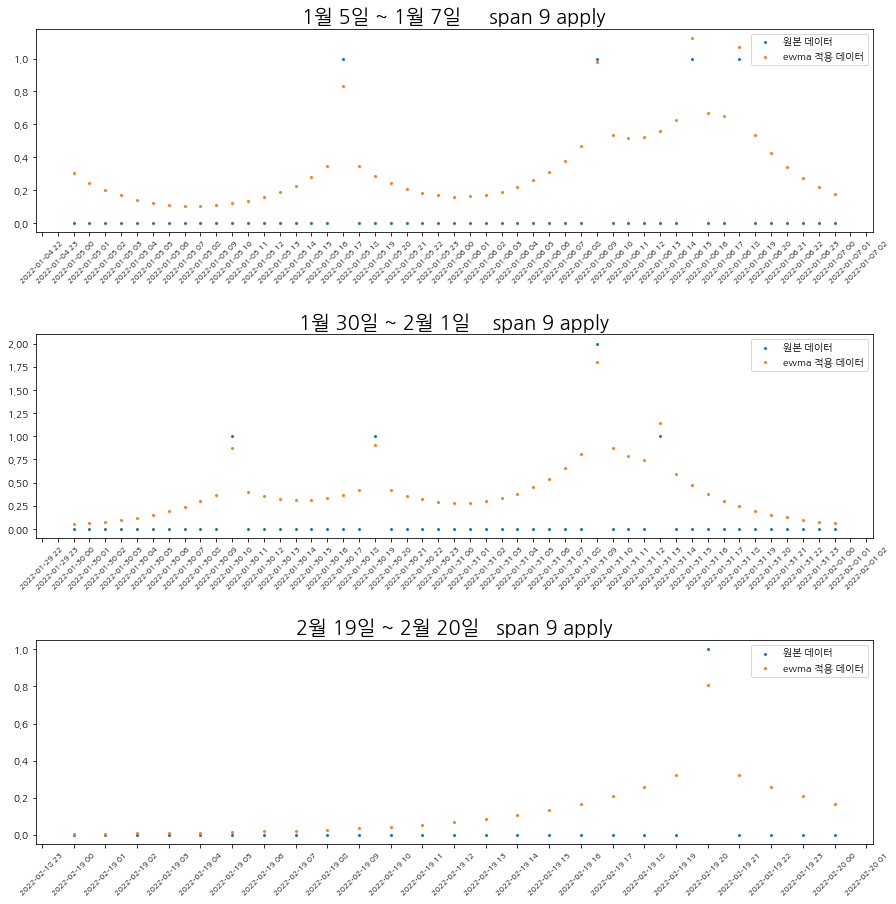

In [31]:
for factor in np.arange(1,10) :
    test_data = data_processing('../../test.csv' , factor, moving_average_span_both)
    #detail_veiw_ewma_plot(test_data , f'  span  {factor}apply')
    detail_veiw_ewma_scatter(test_data,f'   span {factor} apply')

## halflife scatter
1 ~ 10 까지 1 단위로 계산

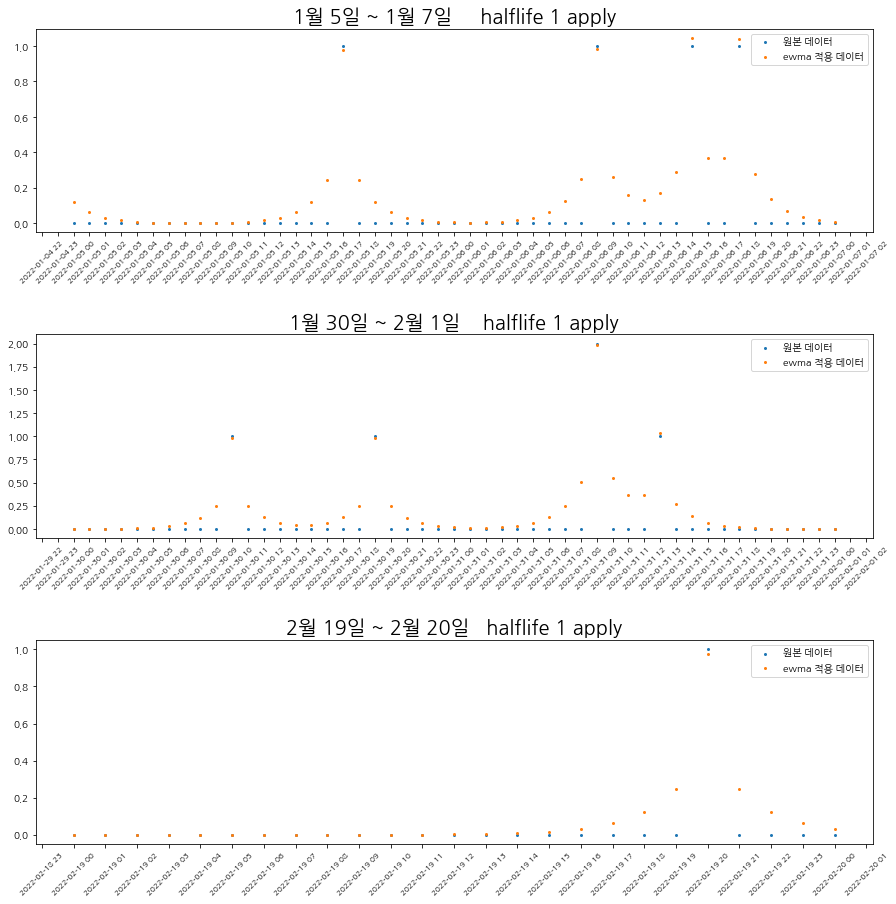

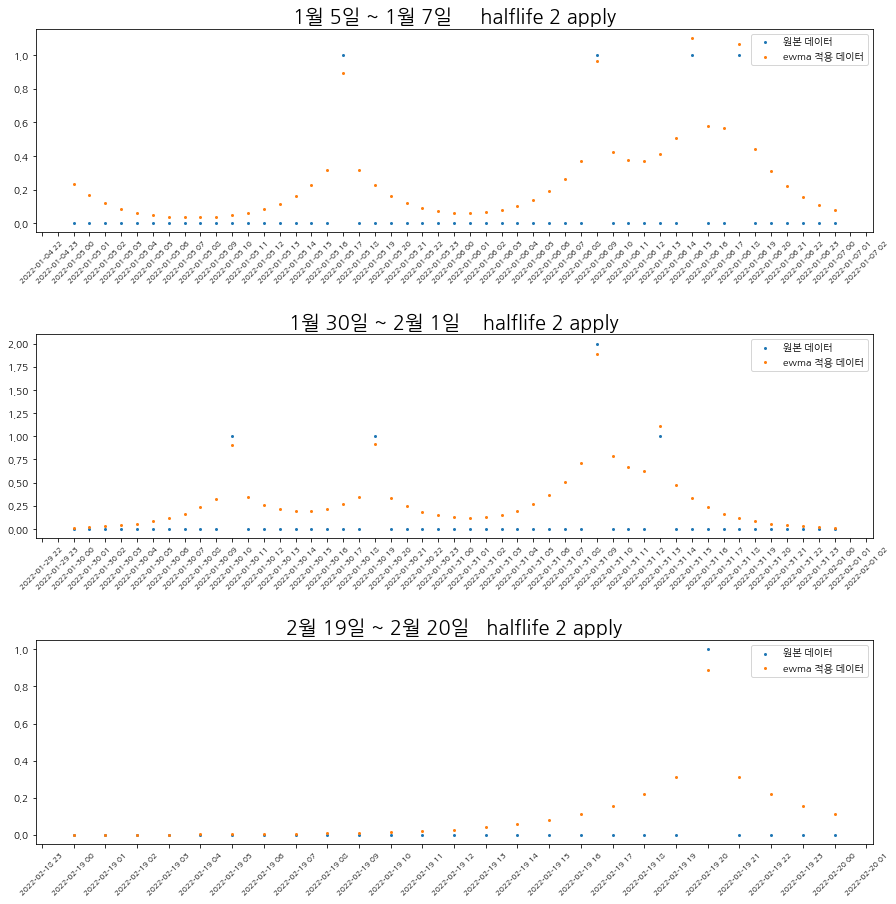

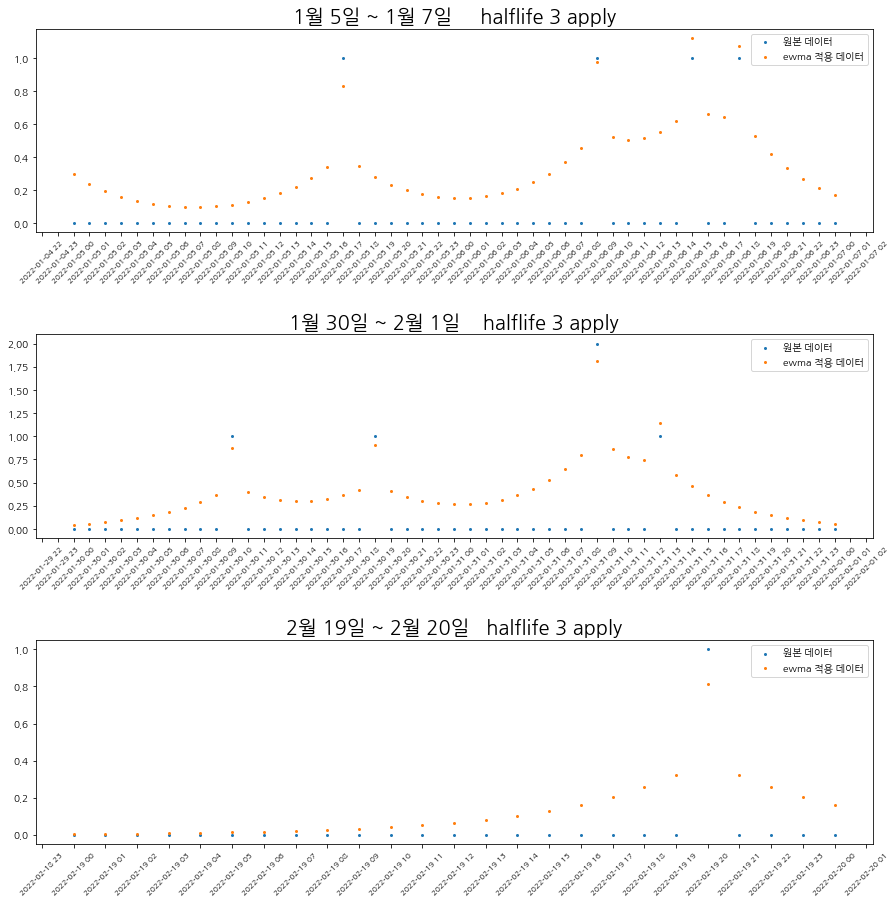

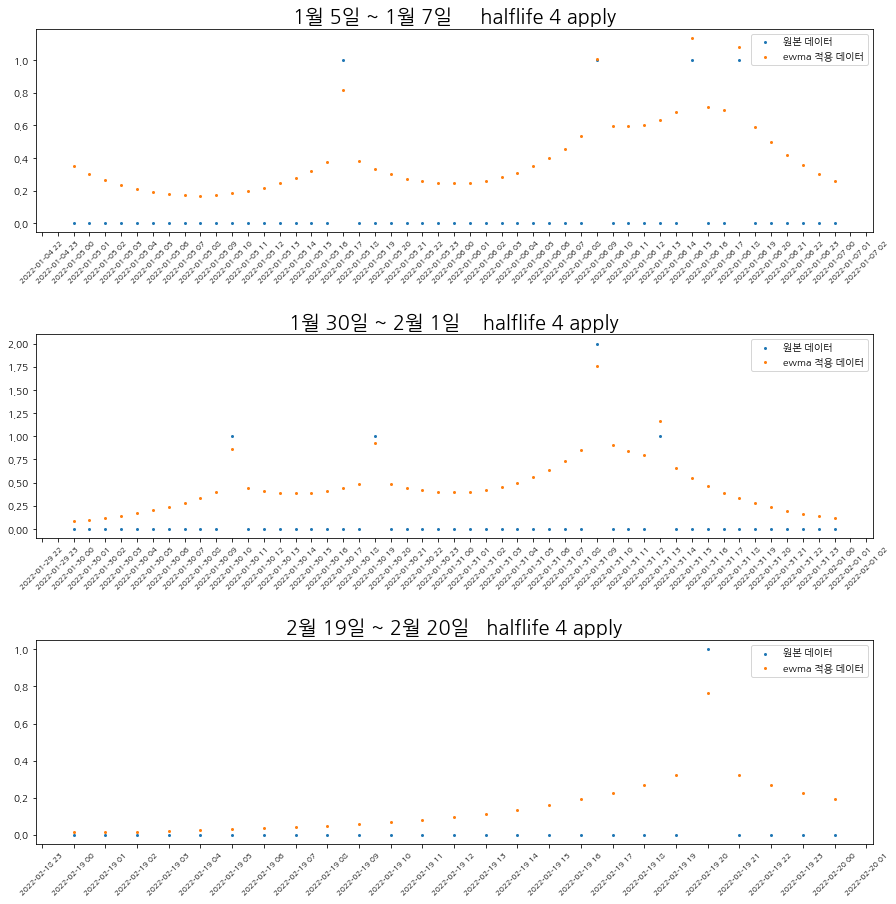

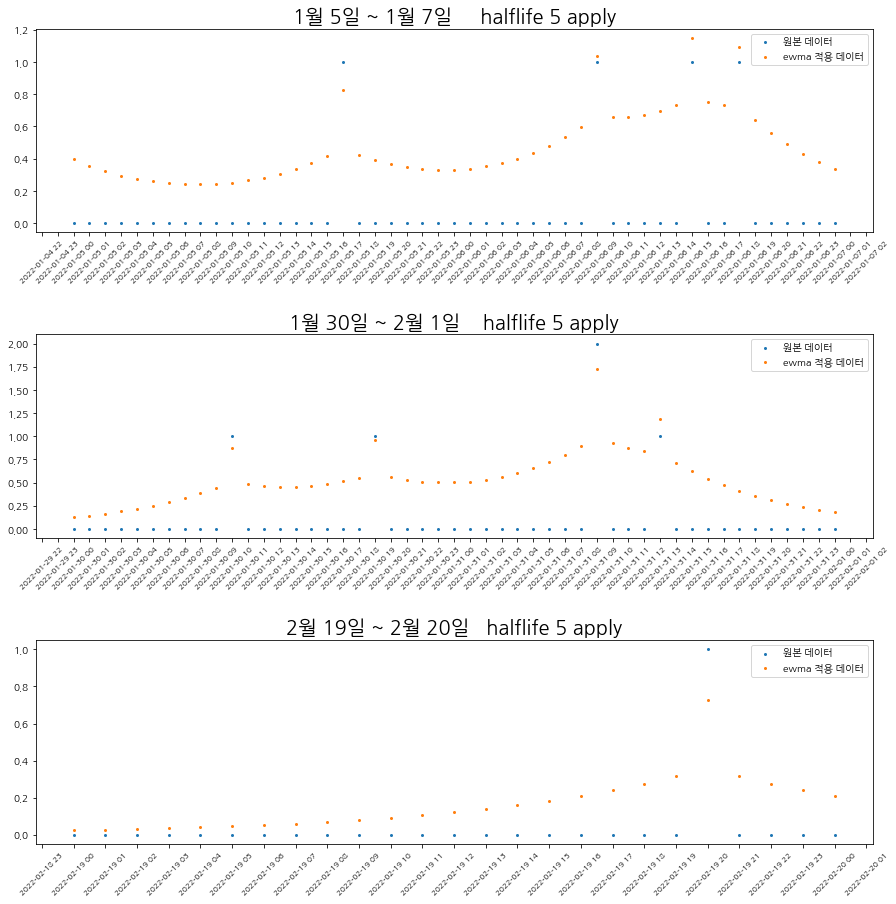

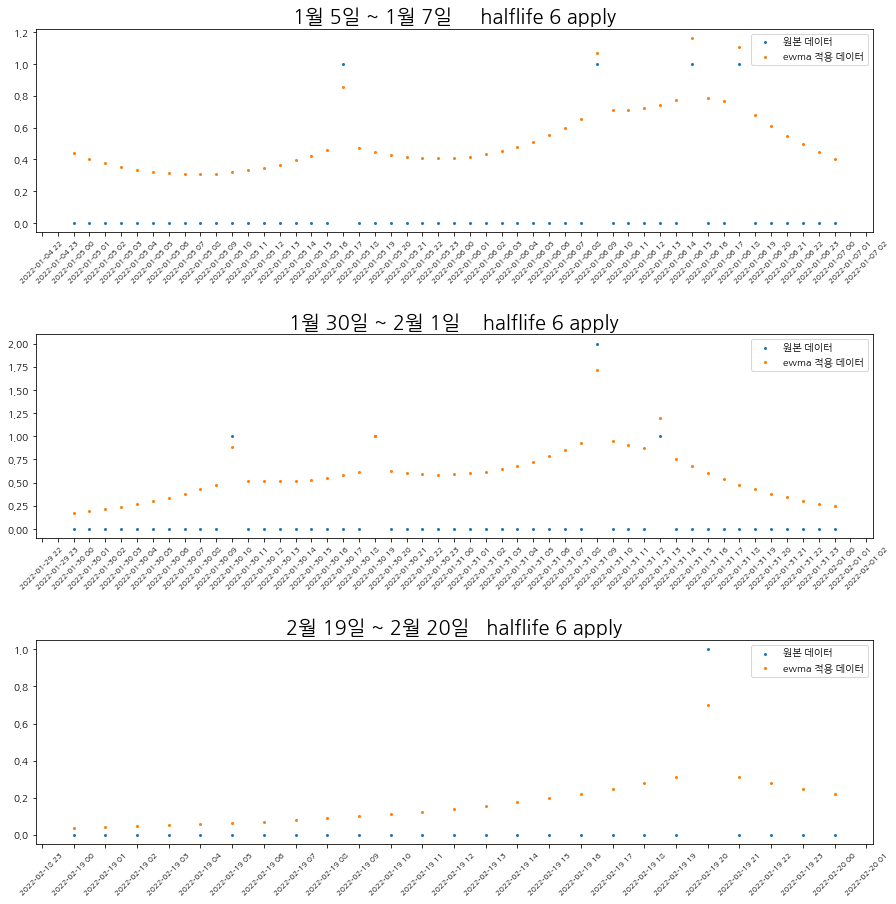

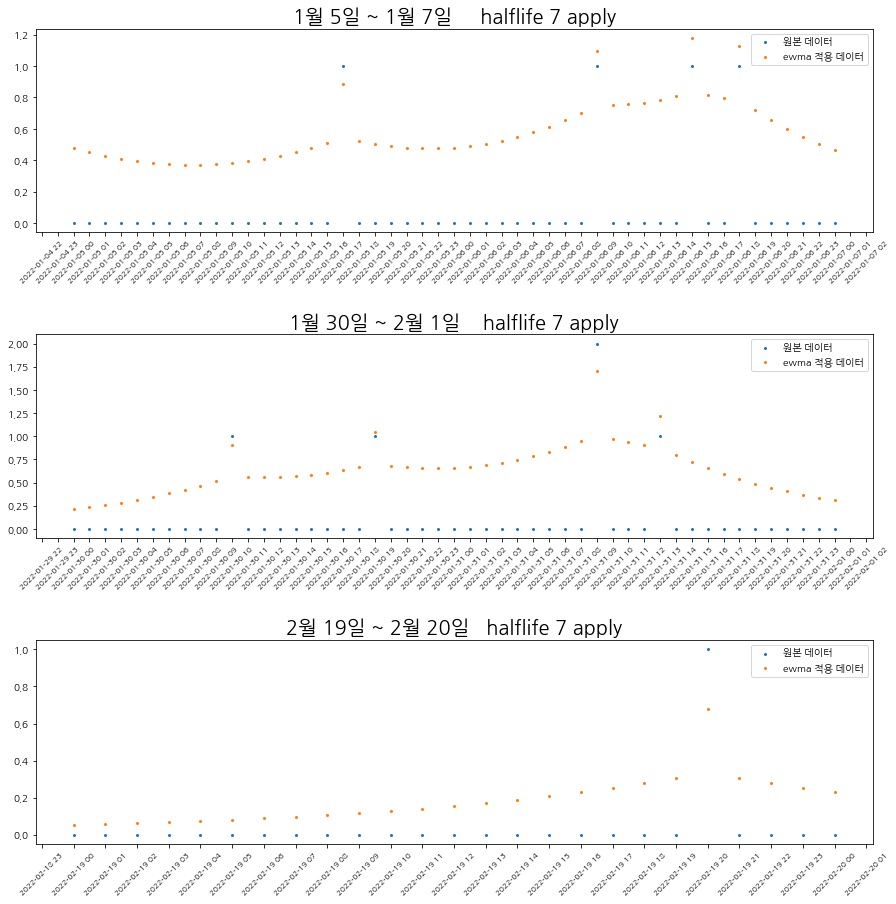

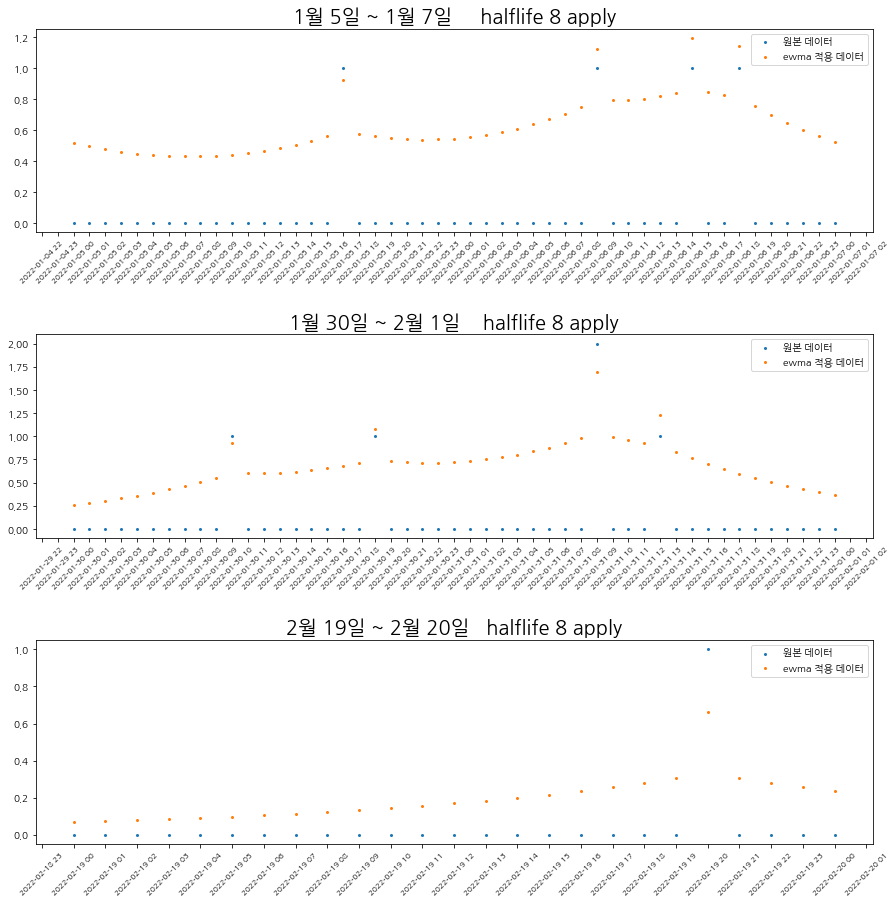

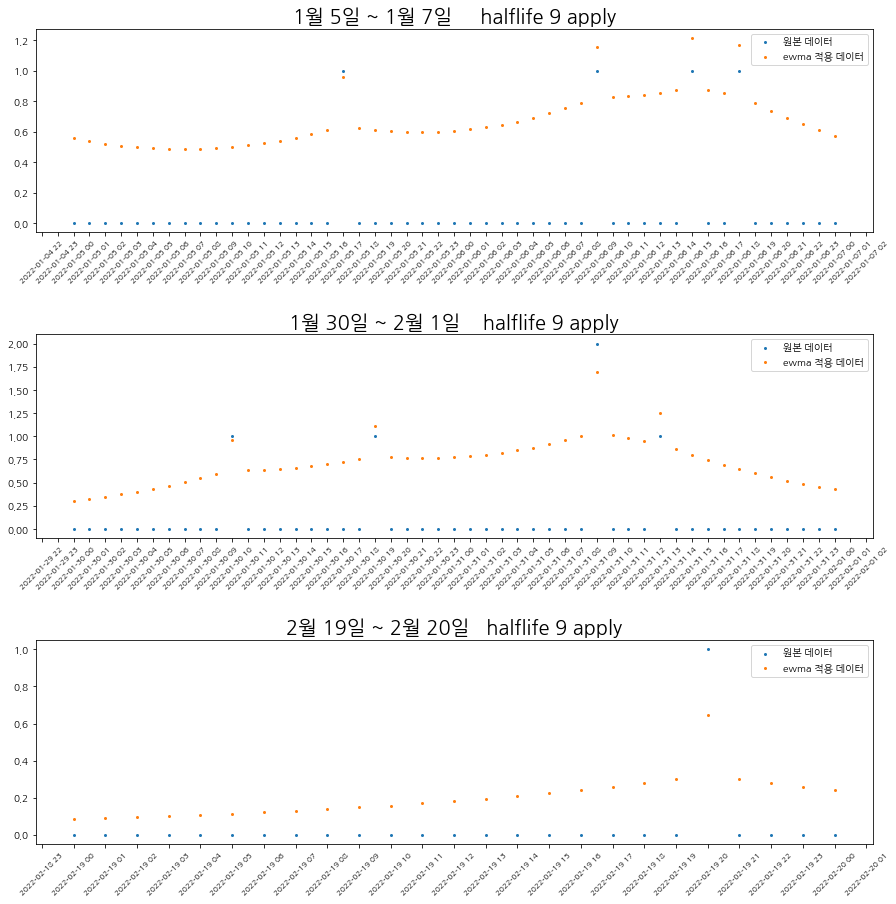

In [32]:
for factor in np.arange(1,10) :
    test_data = data_processing('../../test.csv' , factor, moving_average_halflife_both)
    #detail_veiw_ewma_plot(test_data , f'   halflife {factor} apply')
    detail_veiw_ewma_scatter(test_data,f'   halflife {factor} apply')